<a href="https://colab.research.google.com/github/aurelianmoge/CE-4110-UVa-personal-work/blob/main/HW3_CE_6250_Moge_(notebook).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Power Capacity Expansion Problem

Install packages, setup Gurobi license and read in data. $\color{red}{\text{Add the codes for your license.}}$

In [1]:
!pip install gurobipy
!pip install gurobipy_pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 42.9 MB/s eta 0:00:00


In [2]:
import gurobipy as gp
from gurobipy import GRB
import gurobipy_pandas as gppd
import pandas as pd
import numpy as np
from google.colab import drive

# allow access to google drive
drive.mount('/content/drive')

# read in data
generators = pd.read_csv("drive/MyDrive/CE-6250/expansion data/generators_for_expansion.csv", index_col = "G")
generators.index.name = "Source"

demand = pd.read_csv("drive/MyDrive/CE-6250/expansion data/demand_for_expansion.csv", index_col = "Hour")
demand = demand["Demand"] # coerce from datatype pd.DataFrame to pd.Series (important later on)

# create environment with Gurobi academic license
# CHANGE THESE TO THE VALUES FOR YOUR LICENSE
params = {
"WLSACCESSID": '9da6d4c6-c702-4660-9de1-2abddd3bc8a7',
"WLSSECRET": 'e533d345-3a98-4d56-8057-93cce529b97f',
"LICENSEID": 2865200
}
env = gp.Env(params=params)

Mounted at /content/drive
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2865200
Academic license 2865200 - for non-commercial use only - registered to xm___@virginia.edu


**Question 1A and 1B**

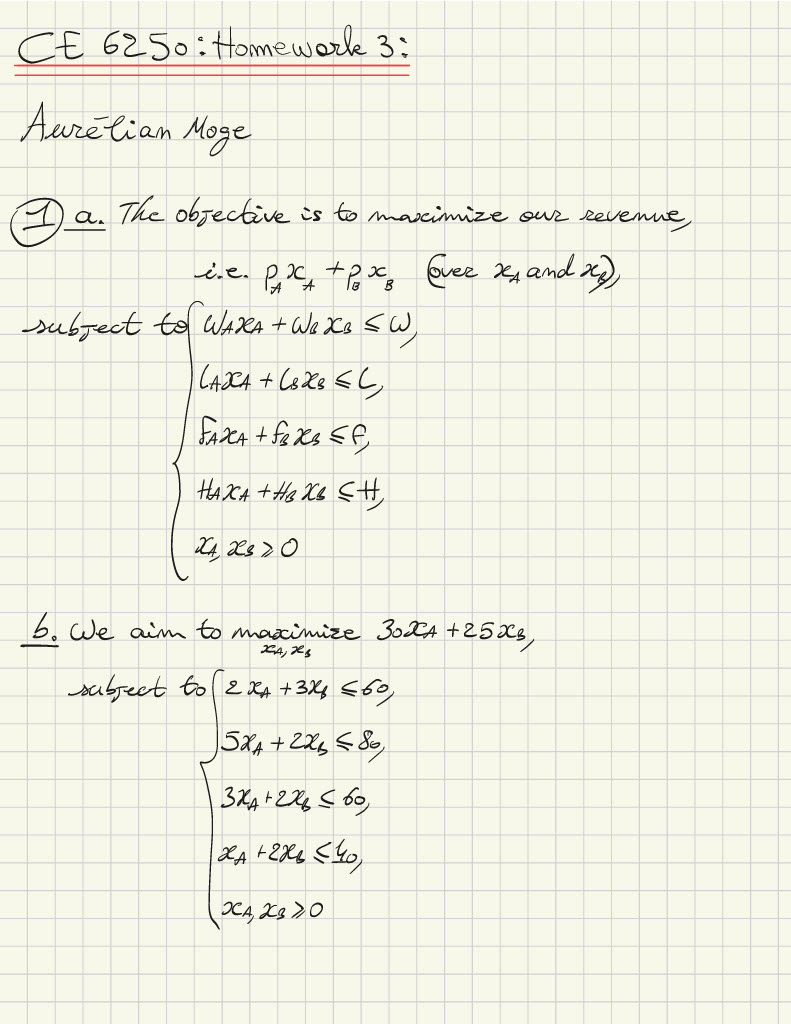

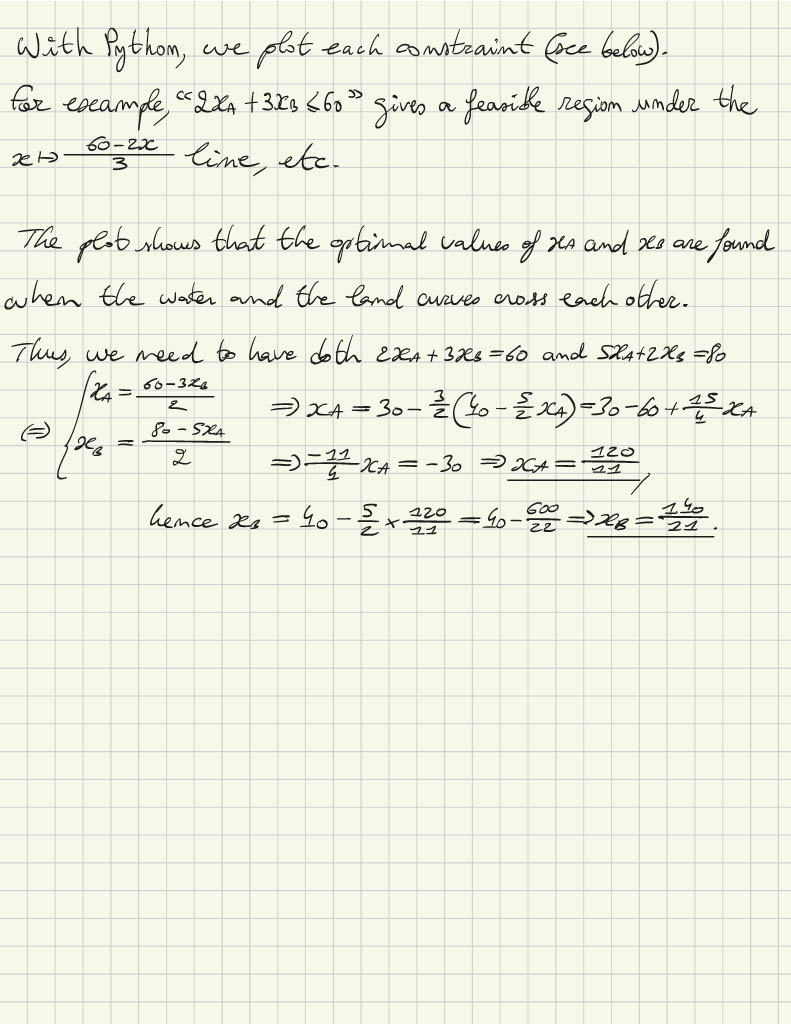

**Question 1B**

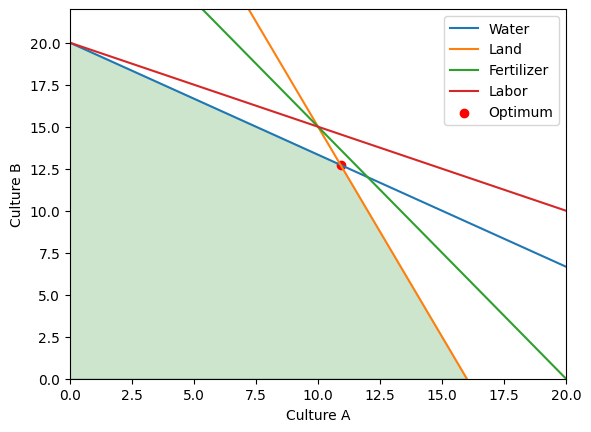

A = 10.909090909090908 B = 12.727272727272727
Maximal revenue = 645.4545454545455


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# We set the diagram
x = np.linspace(0, 20, 200)

# We plot each constraint
plt.plot(x, (60 - 2*x)/3, label="Water")
plt.plot(x, (80 - 5*x)/2, label="Land")
plt.plot(x, (60 - 3*x)/2, label="Fertilizer")
plt.plot(x, (40 - x)/2, label="Labor")

# One can see on the plot that the optimal value will be found when the blue (water) and the fellow (land) curves cross.
# Thus, we look for their intersection.

# Feasible region
A = [0, 16, 120/11, 0]
B = [0, 0, 140/11, 20]
plt.fill(A, B, alpha=0.2, color="green")

plt.scatter(120/11, 140/11, color="red", label="Optimum")
plt.xlim(0, 20)
plt.ylim(0, 22)
plt.xlabel("Culture A")
plt.ylabel("Culture B")
plt.legend()
plt.show()

print("A =", 120/11, "B =", 140/11)
print("Maximal revenue =", 30*(120/11) + 25*(140/11))

**Question 1C**

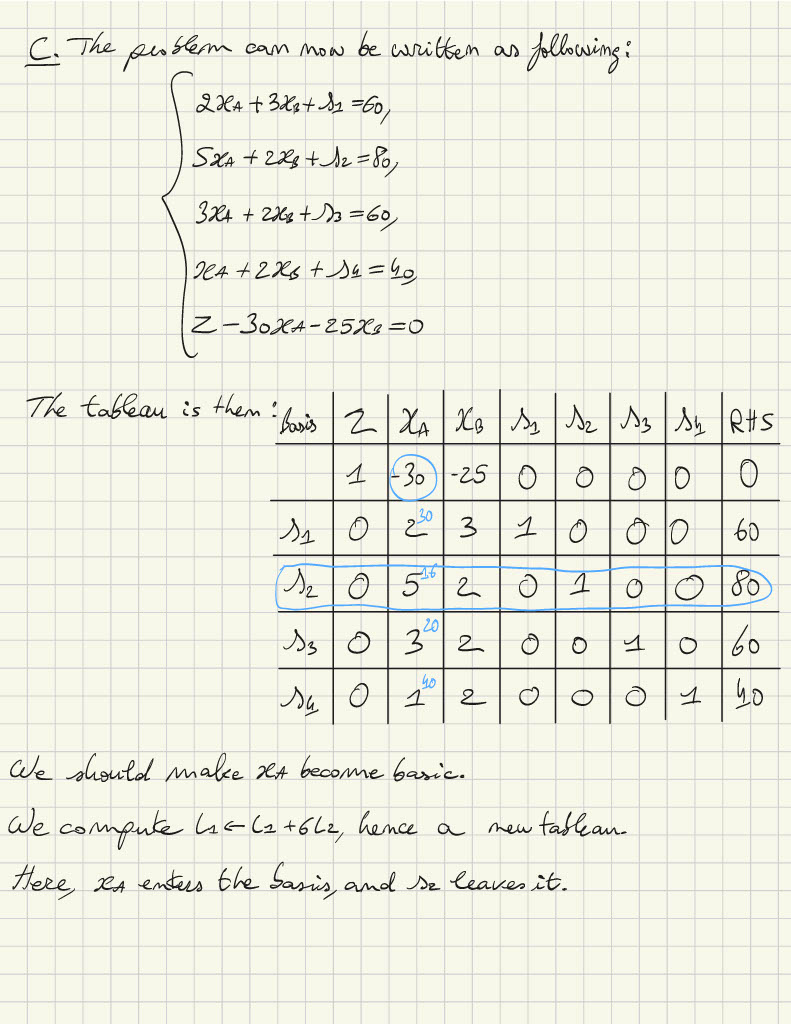

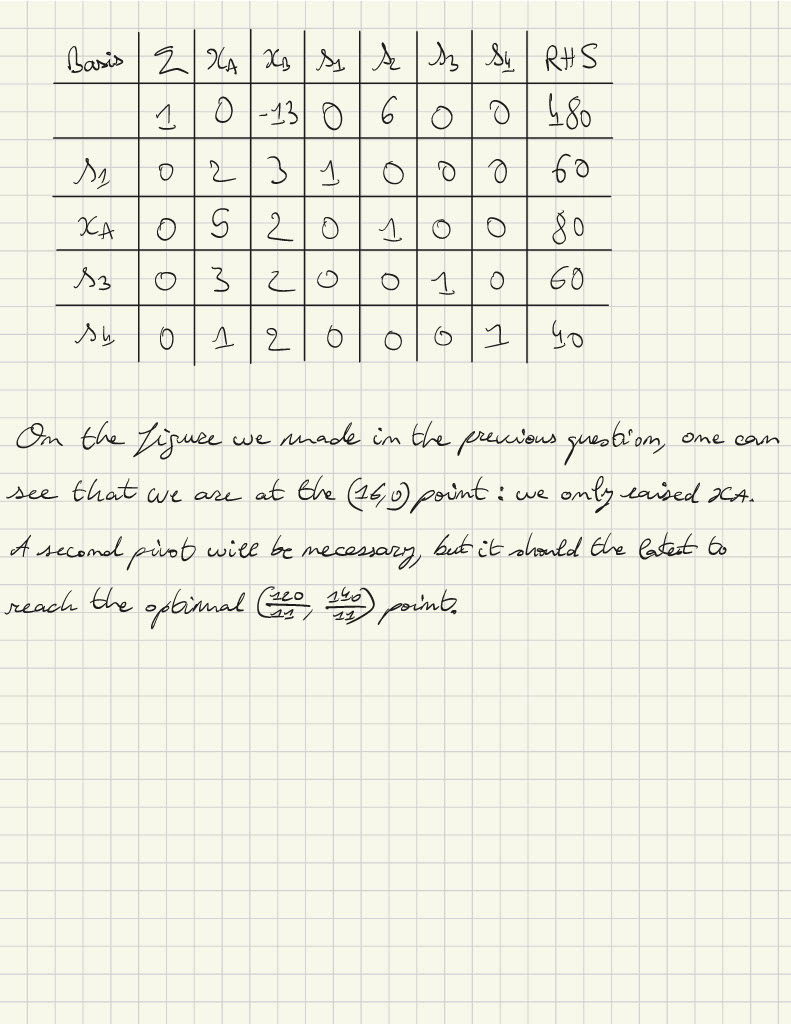

In [4]:
from scipy.optimize import linprog

resultat = linprog(
    c=[60, 80, 60, 40],
    A_ub=[
        [-2, -5, -3, -1],  # culture A
        [-3, -2, -2, -2]   # culture B
    ],
    b_ub=[-30, -25],
    bounds=(0, None),
    method="highs"
)

print("Success :", resultat.success)
print("Dual values :", resultat.x)
print("Optimal value :", resultat.fun)

Success : True
Dual values : [5.90909091 3.63636364 0.         0.        ]
Optimal value : 645.4545454545455


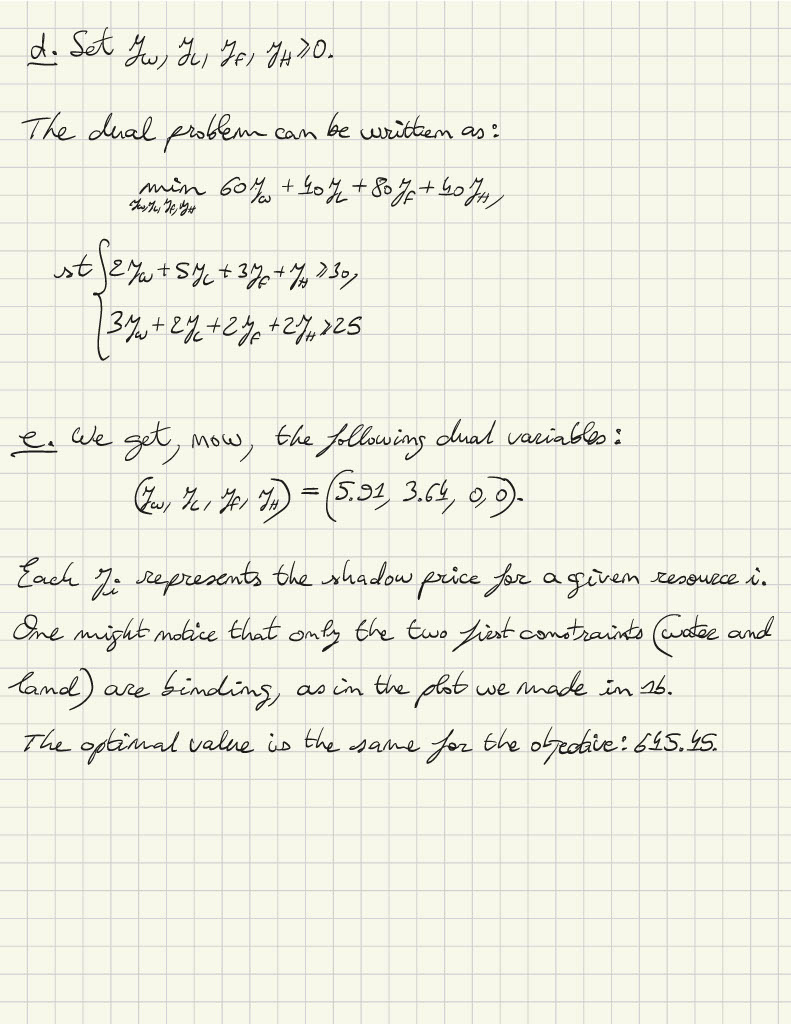

## Optimization only considering thermal power plants (from class)

In [5]:
# parameters
NSEcost = 9000

# Create the model within the Gurobi environment
model = gp.Model('Capacity Expansion',env=env)

# create dataframes to contain gurobi variables, gurobi constrants, and parameters
## by source
df_by_src = generators.loc[:, ['FixedCost', 'VarCost']].copy()
df_by_src.loc["NSE", 'FixedCost'] = 0 # consider NSE a generator with no fixed cost
df_by_src.loc["NSE", 'VarCost'] = NSEcost # variable cost of NSE is NSEcost
df_by_src.drop(["Wind","Solar"],axis=0,inplace=True) # drop wind and solar for now

## by source and hour
### create multi-indexed dataframe for each decision variable index
list_of_indices = [
    list(df_by_src.index),
    list(demand.index) # hours
]

multi_idx = pd.MultiIndex.from_product(list_of_indices, names=["Source", "Hour"])

df_by_hr = pd.DataFrame(index = multi_idx)

# default bounds are [0,infinity) unless otherwise specified, so do not need to specify bounds
GEN = df_by_hr.gppd.add_vars(model, name = "gen_MWh", vtype=GRB.CONTINUOUS)
CAP = df_by_src.gppd.add_vars(model, name = "cap_MW", vtype=GRB.CONTINUOUS)

# non-negativity constraints assumed, just add demand and capacity constraints
# pandas.Dataframe.join documentation: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.join.html
c1_capacity = gppd.add_constrs(
    model, GEN['gen_MWh'], GRB.LESS_EQUAL, GEN.join(CAP['cap_MW'])['cap_MW'], name="c1_capacity"
)

# pandas.Dataframe.groupby documentation:  https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
c2_demand = gppd.add_constrs(
    model, GEN['gen_MWh'].groupby(level = "Hour").sum(), # this sums all power generated from all sources each hour
    GRB.EQUAL, demand, name="c2_demand" # demand needed to be a pd.Series datatype here
)

# objective function
gen_costs = (df_by_src["VarCost"] * GEN["gen_MWh"]).agg(gp.quicksum) # includes NSE penalty
fixed_costs = (df_by_src["FixedCost"] * CAP['cap_MW']).agg(gp.quicksum)

model.setObjective(gen_costs + fixed_costs)

model.write('capacity_expansion.lp')
model.optimize()

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2865200 - for non-commercial use only - registered to xm___@virginia.edu
Optimize a model with 52560 rows, 43805 columns and 131400 nonzeros (Min)
Model fingerprint: 0xc96792b5
Model has 35044 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+01, 6e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+03, 5e+03]

Presolve removed 8760 rows and 1 columns
Presolve time: 0.26s
Presolved: 43800 rows, 43804 columns, 113880 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   8.608670e+05   0.000000e+00      0s
    5729    9.9087398e+08   0.000000e+00   0.000000e+00      0s

Use crossover to convert LP symmetric solution to basi

In [6]:
# process capacity expansion results
cap = CAP.cap_MW.gppd.x
cap_share = cap/np.max(demand)*100 # percent of max demand (we want to be sure we can meet this)
cap_share.name = "cap_share_of_peak_demand" # name the pandas series (this will become the column header when we
                                            # add it to our results dataframe)

# process energy generation results
gen = GEN.gen_MWh.gppd.x.groupby(level = "Source").sum() # sum power generated by source
genshare = gen / np.sum(demand)*100 # compute the fraction of demand met by each source
genshare.name = "gen_share_of_total_demand"
gen = gen / 1000 # convert from MWh to GWh
gen.name = "Gen_GWh"

# Pandas concat documentation: https://pandas.pydata.org/docs/reference/api/pandas.concat.html
df_results = pd.concat([cap,cap_share, gen, genshare], axis = 1) # axis = 1 because we are combining columns rather than rows

df_results.loc['SUM', :] = df_results.sum() # add a row equal to the sum of each column as a check

df_results

,cap_MW,cap_share_of_peak_demand,Gen_GWh,gen_share_of_total_demand
Source,,,,
Geo,0.0,0.000000,0.000,0.000000
Coal,0.0,0.000000,0.000,0.000000
CCGT,3328.0,69.146063,22139.366,98.101148
CT,1290.0,26.802410,427.894,1.896030
NSE,195.0,4.051527,0.637,0.002823
SUM,4813.0,100.000000,22567.897,100.000000


## 1. Power Capacity Expansion

## a) Considering renewables (20 pts)

Create a new model, model2 that includes renewables. To do this, add renewables back to df_by_src and df_by_hr. Also include a column in df_by_hr for the capacity factors.
$\color{red}{\text{The code below is complete.}}$

In [7]:
# create dataframes to contain gurobi variables, gurobi constrants, and parameters
## by source
df_by_src = generators.loc[:, ['FixedCost', 'VarCost']].copy()
df_by_src.loc["NSE", 'FixedCost'] = 0 # consider NSE a generator with no fixed cost
df_by_src.loc["NSE", 'VarCost'] = NSEcost # variable cost of NSE is NSEcost

df_by_src

,FixedCost,VarCost
Source,,
Geo,563500.0,0.0
Coal,270280.0,24.2
CCGT,82400.0,27.6
CT,62888.0,43.8
Wind,91000.0,0.0
Solar,50850.0,0.0
NSE,0.0,9000.0


In [8]:
# Read in capacity factors for wind and solar
capacity_factors = pd.read_csv("drive/MyDrive/CE-6250/expansion data//wind_solar_for_expansion.csv", index_col = "Hour")
capacity_factors.head()

### re-organize wide to long using pd.DataFrame.stack()
# documentation: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.stack.html
capacity_factors = capacity_factors.T.stack()
capacity_factors.index.names = ["Source", "Hour"]
capacity_factors.name = "capfac"
capacity_factors

# redefine df_by_hr so that it includes Wind and Solar
## by source and hour
### create multi-indexed dataframe for each decision variable index
list_of_indices = [
    list(df_by_src.index),
    list(demand.index) # hours
]

multi_idx = pd.MultiIndex.from_product(list_of_indices, names=["Source", "Hour"])
# create dataframe
df_by_hr = pd.DataFrame(index = multi_idx)
# add the capacity factors
df_by_hr = df_by_hr.join(capacity_factors)

# fillna(1) puts a capacity factor of 1 for generators that have no capacity factor data (generators other than wind and solar)
df_by_hr = df_by_hr.fillna(1)

df_by_hr

capfac
Source Hour        
Geo    1        1.0
       2        1.0
       3        1.0
       4        1.0
       5        1.0
...             ...
NSE    8756     1.0
       8757     1.0
       8758     1.0
       8759     1.0
       8760     1.0

[61320 rows x 1 columns]

In [9]:
# Create the model within the Gurobi environment
model2 = gp.Model('Capacity Expansion with Renewables',env=env)

$\color{red}{\text{Edit the code below to adapt the decision variables, constraints, and objective function with renewables included.}}$

In [10]:
### Decision variables (nonnegative by default)
GEN = df_by_hr.gppd.add_vars(model2, name="gen_MWh", vtype=GRB.CONTINUOUS)
CAP = df_by_src.gppd.add_vars(model2, name="cap_MW", vtype=GRB.CONTINUOUS)


### Constraints

# Equation 14
c2_demand = gppd.add_constrs(
    model2,
    GEN["gen_MWh"].groupby(level="Hour").sum(),
    GRB.EQUAL,
    demand,
    name="c2_demand"
)

# Equations 15-16
c1_capacity = gppd.add_constrs(
    model2,
    GEN["gen_MWh"],
    GRB.LESS_EQUAL,
    GEN.join(CAP["cap_MW"])["cap_MW"] * GEN["capfac"],
    name="c1_capacity"
)


### Objective function

# Equation 13
gen_costs = (df_by_src["VarCost"] * GEN["gen_MWh"]).agg(gp.quicksum)
fixed_costs = (df_by_src["FixedCost"] * CAP["cap_MW"]).agg(gp.quicksum)


### Solving the model

model2.setObjective(gen_costs + fixed_costs)
model2.write("capacity_expansion_renewables.lp")
model2.optimize()

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2865200 - for non-commercial use only - registered to xm___@virginia.edu
Optimize a model with 70080 rows, 61327 columns and 179496 nonzeros (Min)
Model fingerprint: 0xc7a90ab0
Model has 35046 linear objective coefficients
Coefficient statistics:
  Matrix range     [5e-05, 1e+00]
  Objective range  [2e+01, 6e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+03, 5e+03]

Presolve removed 13224 rows and 4465 columns
Presolve time: 0.50s
Presolved: 56856 rows, 56862 columns, 153048 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   2.820987e+06   0.000000e+00      1s
   29387    8.2832374e+08   8.926081e+03   0.000000e+00      5s
   30215    8.2899894e+08   0.000000e+00   0.000000

$\color{red}{\text{Print the results. The code below is complete.}}$

In [11]:
# process capacity expansion results
cap = CAP.cap_MW.gppd.x
cap_share = cap/np.max(demand)*100 # percent of max demand (we want to be sure we can meet this)
cap_share.name = "cap_share_of_peak_demand" # name the pandas series (this will become the column header when we
                                            # add it to our results dataframe)

# process energy generation results
gen = GEN.gen_MWh.gppd.x.groupby(level = "Source").sum() # sum power generated by source
genshare = gen / np.sum(demand)*100 # compute the fraction of demand met by each source
genshare.name = "gen_share_of_total_demand"
gen = gen / 1000 # convert from MWh to GWh
gen.name = "Gen_GWh"

# Pandas concat documentation: https://pandas.pydata.org/docs/reference/api/pandas.concat.html
df_results2 = pd.concat([cap,cap_share, gen, genshare], axis = 1) # axis = 1 because we are combining columns rather than rows

df_results2.loc['SUM', :] = df_results2.sum() # add a row equal to the sum of each column as a check

df_results2

,cap_MW,cap_share_of_peak_demand,Gen_GWh,gen_share_of_total_demand
Source,,,,
Geo,0.000000,0.000000,0.000000,0.000000
Coal,0.000000,0.000000,0.000000,0.000000
CCGT,2422.855353,50.339816,11367.656651,50.370917
CT,1419.783433,29.498929,453.979742,2.011617
Wind,349.955730,7.271052,1019.468466,4.517339
Solar,3362.768069,69.868441,9726.392813,43.098357
NSE,136.513320,2.836346,0.399328,0.001769
SUM,7691.875906,159.814584,22567.897000,100.000000


## b) Considering Renewables and Retirements (20 pts)

Add information on the old generators to the data frame.
$\color{red}{\text{The code below is complete.}}$

In [12]:
# Add data on old generators to dataframe
generators.loc["Old_CCGT",:] = ["Existing CCGT",0,40000,5,7.5,4,0,0,0,0,40000,30]
generators.loc["Old_CT",:] = ["Existing CT",0,30000,11,11.0,4,0,0,0,0,30000,55]

# Set installed capacity for existing CCGTs:
ExistingCap_CCGT = 1260 # Approximate actual existing capacity in SDGE
ExistingCap_CT = 925 # Approximate actual existing capacity in SDGE
# Add new column to generators Data Frame
generators["ExistingCap"] = [0,0,0,0,0,0,ExistingCap_CCGT,ExistingCap_CT]
generators

,Description,Capex,FixedOM,VarOM,HeatRate,FuelCost,WACC,AssetLife,CRF,Annuity,FixedCost,VarCost,ExistingCap
Source,,,,,,,,,,,,,
Geo,Geothermal,7500000.0,130000.0,0.0,28.4,0.0,0.040,30.0,0.0578,433500.0,563500.0,0.0,0
Coal,Supercritical Coal,2600000.0,120000.0,8.0,8.1,2.0,0.040,30.0,0.0578,150280.0,270280.0,24.2,0
CCGT,Natural gas CCGT,1000000.0,28000.0,2.0,6.4,4.0,0.035,30.0,0.0544,54400.0,82400.0,27.6,0
CT,Natural gas CT,770000.0,21000.0,5.0,9.7,4.0,0.035,30.0,0.0544,41888.0,62888.0,43.8,0
Wind,Onshore wind,1000000.0,40000.0,0.0,1.0,0.0,0.030,30.0,0.0510,51000.0,91000.0,0.0,0
Solar,Tracking solar PV,750000.0,15000.0,0.0,1.0,0.0,0.025,30.0,0.0478,35850.0,50850.0,0.0,0
Old_CCGT,Existing CCGT,0.0,40000.0,5.0,7.5,4.0,0.000,0.0,0.0000,0.0,40000.0,30.0,1260
Old_CT,Existing CT,0.0,30000.0,11.0,11.0,4.0,0.000,0.0,0.0000,0.0,30000.0,55.0,925


Create a new model, model3, that includes old generators. To do this, create separate data frames by src and by hr of both old and new generators. $\color{red}{\text{The code below is complete.}}$

In [13]:
# create dataframes to contain gurobi variables, gurobi constrants, and parameters
## by source
df_by_src = generators.loc[:, ['FixedCost', 'VarCost','ExistingCap']].copy()
df_by_src.loc["NSE", 'FixedCost'] = 0 # consider NSE a generator with no fixed cost
df_by_src.loc["NSE", 'VarCost'] = NSEcost # variable cost of NSE is NSEcost
df_by_src.loc["NSE", 'ExistingCap'] = 0 # variable cost of NSE is NSEcost

df_by_src

,FixedCost,VarCost,ExistingCap
Source,,,
Geo,563500.0,0.0,0.0
Coal,270280.0,24.2,0.0
CCGT,82400.0,27.6,0.0
CT,62888.0,43.8,0.0
Wind,91000.0,0.0,0.0
Solar,50850.0,0.0,0.0
Old_CCGT,40000.0,30.0,1260.0
Old_CT,30000.0,55.0,925.0
NSE,0.0,9000.0,0.0


In [14]:
# separate old and new sources into separate data frames since different constraints apply to each
df_by_oldsrc = df_by_src.loc[["Old_CCGT","Old_CT"]]
df_by_oldsrc

,FixedCost,VarCost,ExistingCap
Source,,,
Old_CCGT,40000.0,30.0,1260.0
Old_CT,30000.0,55.0,925.0


In [15]:
# separate old and new sources into separate data frames since different constraints apply to each
df_by_newsrc = df_by_src.loc[["Geo","Coal","CCGT","CT","Wind","Solar","NSE"]]
df_by_newsrc

,FixedCost,VarCost,ExistingCap
Source,,,
Geo,563500.0,0.0,0.0
Coal,270280.0,24.2,0.0
CCGT,82400.0,27.6,0.0
CT,62888.0,43.8,0.0
Wind,91000.0,0.0,0.0
Solar,50850.0,0.0,0.0
NSE,0.0,9000.0,0.0


In [16]:
# redefine df_by_hr so that it includes Wind and Solar
## by source and hour
### create multi-indexed dataframe for each decision variable index
list_of_indices = [
    list(df_by_src.index),
    list(demand.index) # hours
]

multi_idx = pd.MultiIndex.from_product(list_of_indices, names=["Source", "Hour"])
# create dataframe
df_by_hr = pd.DataFrame(index = multi_idx)
# add the capacity factors
df_by_hr = df_by_hr.join(capacity_factors)

# fillna(1) puts a capacity factor of 1 for generators that have no capacity factor data (generators other than wind and solar)
df_by_hr = df_by_hr.fillna(1)

df_by_hr

capfac
Source Hour        
Geo    1        1.0
       2        1.0
       3        1.0
       4        1.0
       5        1.0
...             ...
NSE    8756     1.0
       8757     1.0
       8758     1.0
       8759     1.0
       8760     1.0

[78840 rows x 1 columns]

In [17]:
# separate old and new sources
idx = pd.IndexSlice
df_by_hr_oldsrc = df_by_hr.loc[idx[["Old_CCGT","Old_CT"],:],:]
df_by_hr_oldsrc

capfac
Source   Hour        
Old_CCGT 1        1.0
         2        1.0
         3        1.0
         4        1.0
         5        1.0
...               ...
Old_CT   8756     1.0
         8757     1.0
         8758     1.0
         8759     1.0
         8760     1.0

[17520 rows x 1 columns]

In [18]:
# separate old and new sources
idx = pd.IndexSlice
df_by_hr_newsrc = df_by_hr.loc[idx[["Geo","Coal","CCGT","CT","Wind","Solar","NSE"],:],:]
df_by_hr_newsrc

capfac
Source Hour        
Geo    1        1.0
       2        1.0
       3        1.0
       4        1.0
       5        1.0
...             ...
NSE    8756     1.0
       8757     1.0
       8758     1.0
       8759     1.0
       8760     1.0

[61320 rows x 1 columns]

In [19]:
# Create the model within the Gurobi environment
model3 = gp.Model('Capacity Expansion and Retirement',env=env)

$\color{red}{\text{Edit the code below to adapt the decision variables,
constraints, and objective function with renewables and old generators included.}}$  
$\color{red}{\text{Capacity decisions apply to df_by_newsrc. Retirement decisions apply to df_by_old_src.}}$  
$\color{red}{\text{Generation decisions apply to df_by_hr_newsrc and df_by_hr_oldsrc.}}$

$\color{red}{\text{Print the results. The code below is complete.}}$

In [20]:
### decision variables (defined as GEN_OLD, GEN_NEW, CAP and RET)
GEN_OLD = df_by_hr_oldsrc.gppd.add_vars(model3, name="gen_MWh", vtype=GRB.CONTINUOUS)

GEN_NEW = df_by_hr_newsrc.gppd.add_vars(model3, name="gen_MWh", vtype=GRB.CONTINUOUS)

CAP = df_by_newsrc.gppd.add_vars(model3, name="cap_MW", vtype=GRB.CONTINUOUS)

RET = df_by_oldsrc.gppd.add_vars(model3, name="ret_MW", vtype=GRB.CONTINUOUS)


### constraints

# Equation 21:
generation_by_hour = (GEN_OLD["gen_MWh"].groupby(level="Hour").sum() + GEN_NEW["gen_MWh"].groupby(level="Hour").sum())

c4_demand = gppd.add_constrs(
    model3,
    generation_by_hour,
    GRB.EQUAL,
    demand,
    name="c4_demand"
)

# Equation 23:
old_capacity = GEN_OLD.join(df_by_oldsrc["ExistingCap"]).join(RET["ret_MW"])

c1_capacity_old = gppd.add_constrs(
    model3,
    GEN_OLD["gen_MWh"],
    GRB.LESS_EQUAL,
    old_capacity["ExistingCap"] - old_capacity["ret_MW"],
    name="c1_capacity_old"
)

# Equations 22-24:
c2_capacity_new = gppd.add_constrs(
    model3,
    GEN_NEW["gen_MWh"],
    GRB.LESS_EQUAL,
    GEN_NEW.join(CAP["cap_MW"])["cap_MW"] * GEN_NEW["capfac"],
    name="c2_capacity_new"
)

# A retirement cannot exceed the existing capacity
c3_retirement = gppd.add_constrs(
    model3,
    RET["ret_MW"],
    GRB.LESS_EQUAL,
    df_by_oldsrc["ExistingCap"],
    name="c3_retirement"
)


### objective function

# Equation 20: variable generation costs
gen_old_costs = (df_by_oldsrc["VarCost"] * GEN_OLD["gen_MWh"]).agg(gp.quicksum)

gen_new_costs = (df_by_newsrc["VarCost"] * GEN_NEW["gen_MWh"]).agg(gp.quicksum)


# Equation 20: fixed costs of retained old capacity and built new capacity
fixed_old_costs = (df_by_oldsrc["FixedCost"] * (df_by_oldsrc["ExistingCap"] - RET["ret_MW"])).agg(gp.quicksum)

fixed_new_costs = (df_by_newsrc["FixedCost"] * CAP["cap_MW"]).agg(gp.quicksum)


### Solving the problem

model3.setObjective(gen_old_costs + gen_new_costs + fixed_old_costs + fixed_new_costs)
model3.write('capacity_expansion_retirement.lp')
model3.optimize()

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2865200 - for non-commercial use only - registered to xm___@virginia.edu
Optimize a model with 87602 rows, 78849 columns and 232058 nonzeros (Min)
Model fingerprint: 0x4d768ab2
Model has 52568 linear objective coefficients and an objective constant of 78150000
Coefficient statistics:
  Matrix range     [5e-05, 1e+00]
  Objective range  [2e+01, 6e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [9e+02, 5e+03]

Presolve removed 13226 rows and 4465 columns
Presolve time: 0.27s
Presolved: 74376 rows, 74384 columns, 205608 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   2.820987e+06   0.000000e+00      0s
   31401    7.2158249e+08   5.481815e+05   0.000000e+00      5s
   36640    7

In [21]:
# process capacity expansion results
cap_new = CAP.cap_MW.gppd.x
cap_new = cap_new.to_frame()
ret_old = RET.ret_MW.gppd.x
ret_old = ret_old.to_frame()

cap_old = df_by_oldsrc['ExistingCap'] - ret_old["ret_MW"]
cap_old = cap_old.to_frame()
cap_old.rename(columns={0:"cap_MW"},inplace=True)
cap = pd.concat((cap_new, cap_old), axis=0) # we correct this line to match with the new Pandas syntax!

cap_share = cap/np.max(demand)*100 # percent of max demand (we want to be sure we can meet this)
cap_share.rename(columns={"cap_MW":"cap_share_of_peak_demand"},inplace=True) # name the pandas series (this will become the column header when we
                                                                              # add it to our results dataframe)

# process energy generation results
gen_old = GEN_OLD.gen_MWh.gppd.x.groupby(level = "Source").sum()
gen_new = GEN_NEW.gen_MWh.gppd.x.groupby(level = "Source").sum()
gen = pd.concat((gen_old,gen_new), axis=0)

genshare = gen / np.sum(demand)*100 # compute the fraction of demand met by each source
genshare.name = "gen_share_of_total_demand"
gen = gen / 1000 # convert from MWh to GWh
gen.name = "Gen_GWh"

# add column for retirements
ret_new = pd.DataFrame(index=cap_new.index,columns=["ret_MW"],data=0.0)
ret = pd.concat((ret_new,ret_old), axis=0)

# Pandas concat documentation: https://pandas.pydata.org/docs/reference/api/pandas.concat.html
df_results3 = pd.concat([cap, cap_share, gen, genshare, ret], axis = 1) # axis = 1 because we are combining columns rather than rows

df_results3.loc['SUM', :] = df_results3.sum() # add a row equal to the sum of each column as a check

df_results3

,cap_MW,cap_share_of_peak_demand,Gen_GWh,gen_share_of_total_demand,ret_MW
Source,,,,,
Geo,0.000000,0.000000,0.000000,0.000000,0.0
Coal,0.000000,0.000000,0.000000,0.000000,0.0
CCGT,1417.311186,29.447563,8545.010158,37.863564,0.0
CT,238.555208,4.956476,105.948376,0.469465,0.0
Wind,385.044564,8.000095,1127.535183,4.996191,0.0
Solar,3357.619431,69.761468,9702.021575,42.990366,0.0
NSE,125.065786,2.598500,0.366094,0.001622,0.0
Old_CCGT,1260.000000,26.179098,2973.404648,13.175373,0.0
Old_CT,925.000000,19.218782,113.610966,0.503418,0.0


## c) Comparison (10 pts)

$\color{red}{\text{Compare the results from class when we did not consider renewable energy to the results from part (a) when we do,}}$
$\color{red}{\text{and the results from part (b) when we also include retirements. What do these differences imply?}}$

In part (b), the optimal objective value is 7,549,411. In part (a), it is 8,289,989. In class, it was even 9,908,739. Thus, considering renewable energy contribuces to reduce the optimal cost, and including retirements as well.

Our purpose was to minimize the total cost subject to certain constraints that are related to the capacity of our power plants, etc. The differences we have shown in this notebook imply that renewable energies and retirements can contribute to lower this cost.